In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/df_feat_eng.csv'
df = pd.read_csv(url)

In [4]:
df.loc[df['Location'] == 'Monte Carlo', 'Location'] = 'Monte Carlo, Monaco'

In [5]:
url_clima = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/weatherATP.csv'
df_clima = pd.read_csv(url_clima)

In [6]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')
df_clima['date'] = pd.to_datetime(df_clima['date'], format='%Y-%m-%d')

In [7]:
print(f'ANTES: Filas: df: {df.shape[0]}, columnas df: {df.shape[1]}')

df = df.merge(df_clima, left_on=['Fecha','Location'], right_on=['date','Ciudad'], how='inner')

print(f'DESPUES: Filas: df: {df.shape[0]}, columnas df: {df.shape[1]}')

ANTES: Filas: df: 16061, columnas df: 75
DESPUES: Filas: df: 16061, columnas df: 92


In [8]:
df = df.drop(columns=['date','Ciudad'])

Empezamos con un análisis univariado de variables categóricas y después pasamos directo al análisis de variables numéricas, que en la mayoría de los casos son variables que fueron creadas por mí. Por último, análisis bivariado y todos los análisis de la variable target.

## Análisis Categóricas

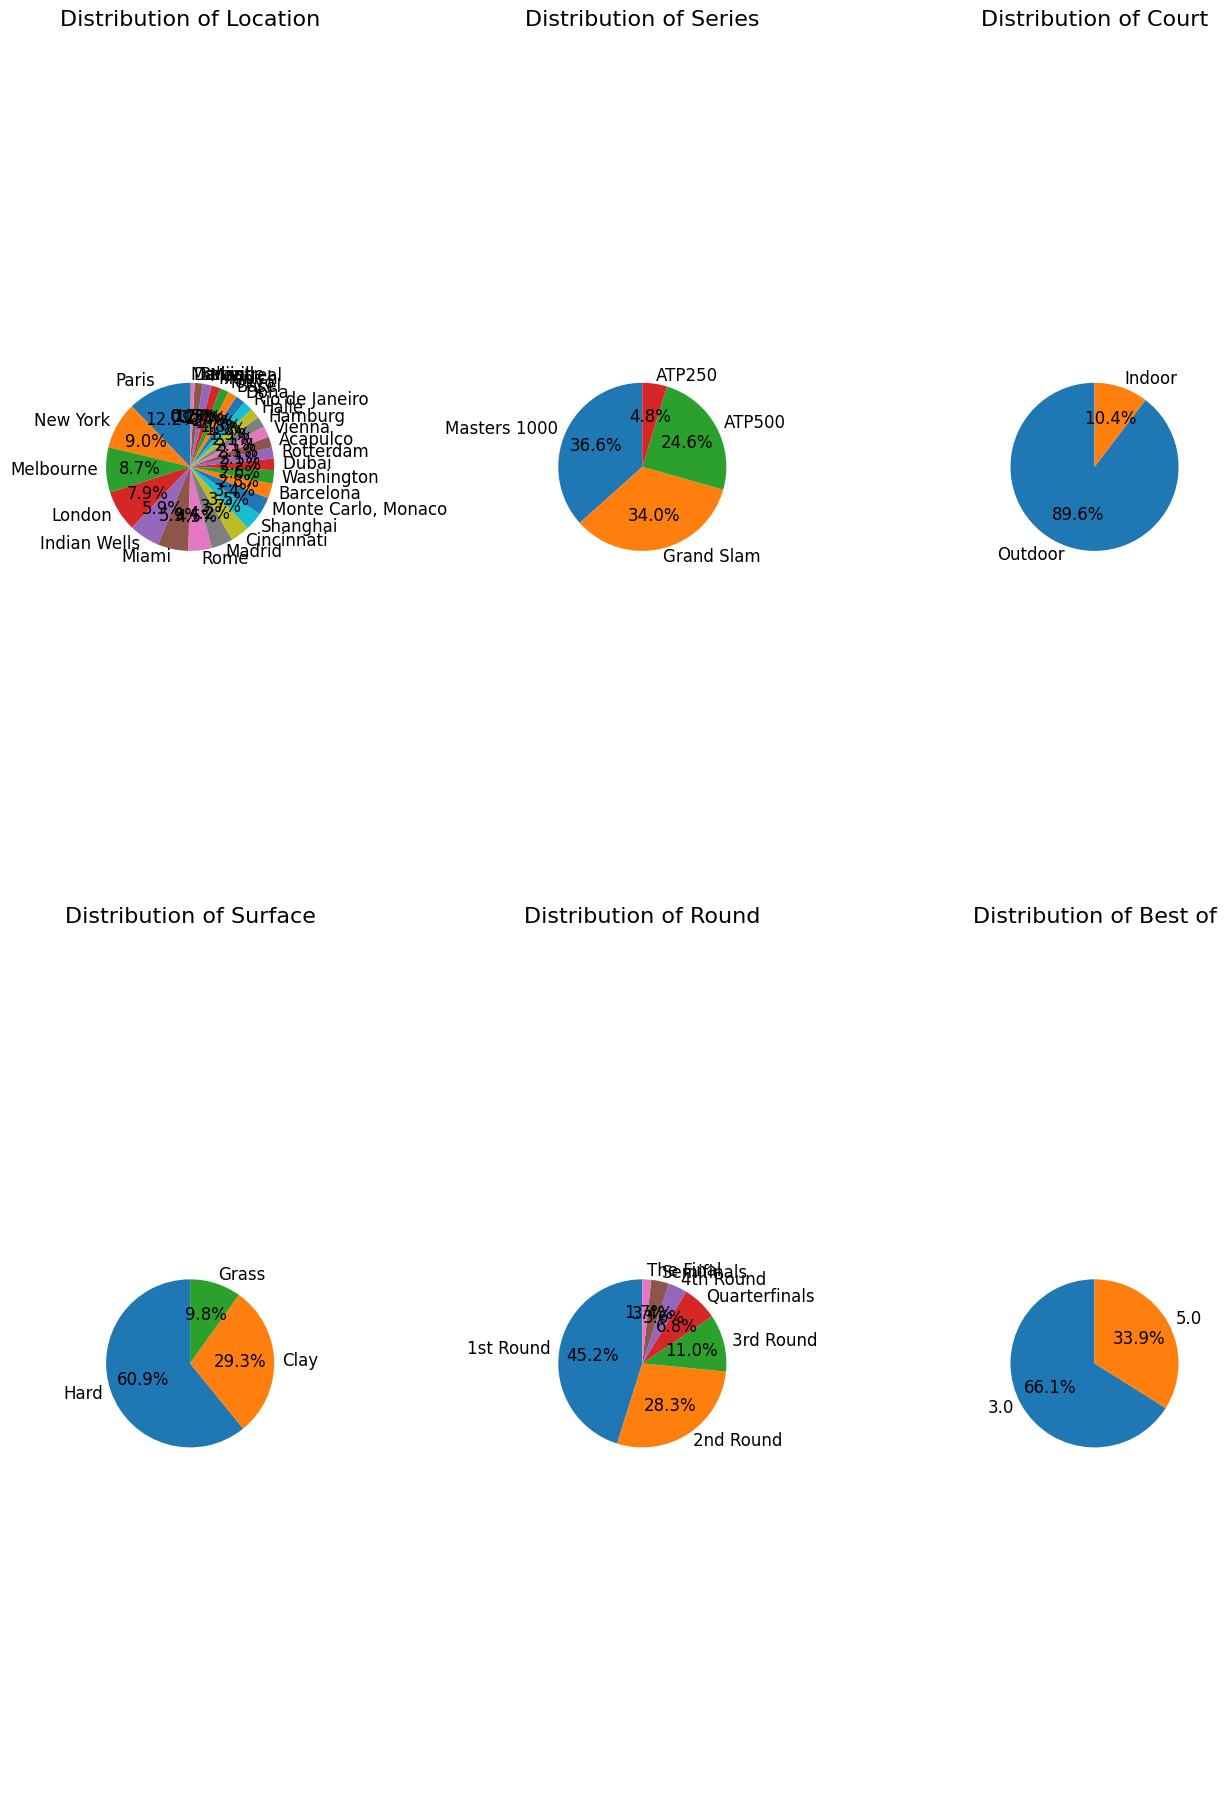

In [9]:
vars_cat = ['Location', 'Series', 'Court', 'Surface', 'Round', 'Best of']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,18))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
  axes[i].pie(df[var].value_counts(),
              labels=df[var].value_counts().index,
              autopct='%1.1f%%',
              startangle=90,
              textprops={'fontsize': 12})
  axes[i].set_title(f'Distribution of {var}', fontsize=16)
  axes[i].axis('equal')

# Hide any unused subplots
for j in range(len(vars_cat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5) # Reduced padding to bring titles closer
plt.show()

*Insights*:
- Las ciudades tiene más o menos la misma cantidad de partidos. Seguramente dependiendo de la cantidad de partidos del torneo hayan acumulado más o menos partidos a lo largo de los años que comprende el dataset
- Tenemos partidos de Grand Slam, Masters 1000 y ATP500 en proporciones similares. Pero de ATP250 no extrajimos datos, ¿cómo es eso posible?
- Casi siempre se juega afuera: el 90% de los partidos
- El pasto como superficie es inusual, algo que tiene mucho sentido si lo analizamos desde un punto de vista tenístico, y la superficie dura abunda como predominante
- Las primeras dos rondas son las que tienen más partidos: lógico, a medida que avanzan las rondas quedan menos participantes y por ende hay menos partidos
- La mayoría de partidos son a 3 sets. Esto tiene correlación intrínseca con el nivel del torneo

Observamos esta curiosidad. Cuando hicimos el scraping, scrapeamos a torneos ATP 500 o superior. Pero como extrajimos los últimos 10 años ocurrió que algunos torneos cambiaron de status (de ATP 250 subieron a ser ATP 500) hace menos tiempo entonces también se registran partidos de ese nivel. Los dejamos en la base.

In [10]:
df['Series'].value_counts()

Series
Masters 1000    5884
Grand Slam      5459
ATP500          3954
ATP250           764
Name: count, dtype: int64

In [11]:
# Ciudades que registran partidos de ATP250
df[df['Series'] == 'ATP250']['Location'].value_counts()

Location
Doha         263
Munich       243
Hamburg      119
Dallas        81
Vienna        31
Marseille     27
Name: count, dtype: int64

Comparamos la cantidad de partidos por ciudad

In [12]:
pd.DataFrame(df['Location'].value_counts()).T

Location,Paris,New York,Melbourne,London,Indian Wells,Miami,Rome,Madrid,Cincinnati,Shanghai,"Monte Carlo, Monaco",Barcelona,Washington,Dubai,Rotterdam,Acapulco,Vienna,Hamburg,Halle,Rio de Janeiro,Doha,Basel,Tokyo,Munich,Montreal,Beijing,Dallas,Marseille
count,1960,1451,1397,1270,950,950,724,670,590,560,548,454,423,355,341,341,341,336,310,304,294,279,279,274,273,248,112,27


## Análisis Numéricas

Variable ATP Ranking
- Distribución muy asimétrica a derecha

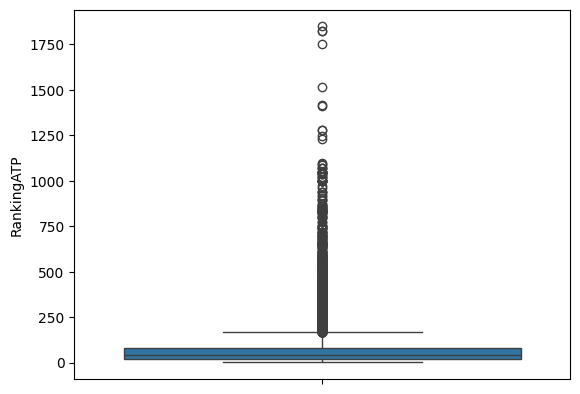

In [13]:
rankATP = pd.concat([df['rankA'], df['rankB']], axis=0).rename('RankingATP')
sns.boxplot(data=rankATP)
plt.show()

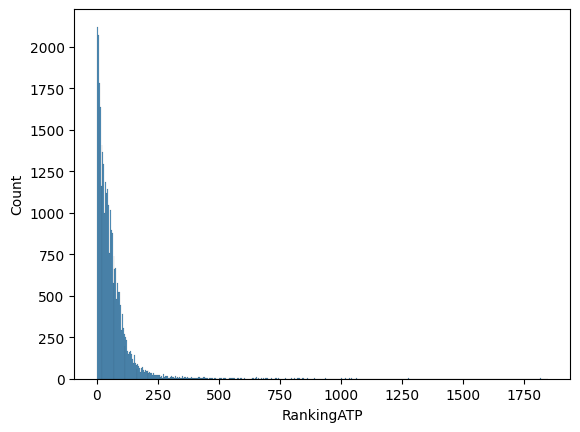

In [14]:
sns.histplot(rankATP)
plt.show()

Vemos distribución de ranking menor a 250

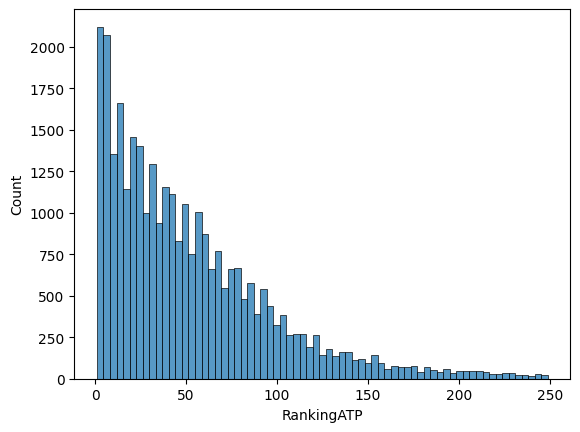

In [15]:
sns.histplot(rankATP[rankATP<250])
plt.show()

Vemos la diferencia de ranking en los partidos

Media de rankDiff: -0.08280928958346305
Mediana de rankDiff: -1.0


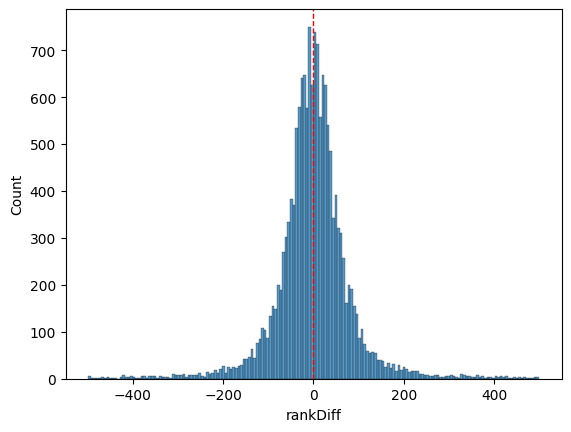

In [16]:
sns.histplot(df[np.abs(df['rankDiff']) < 500]['rankDiff'])
plt.axvline(df['rankDiff'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')

print(f"Media de rankDiff: {df['rankDiff'].mean()}")
print(f"Mediana de rankDiff: {df['rankDiff'].median()}")
plt.show()

O sea que es una distribución muy centrada, de apariencia normal. En promedio el jugador B tiene 1 puesto mejor en el ranking que el jugador A.

Variables relacionadas a Odds:

- Odds de B365 tienen mucha asimetría a derecha. Hay algunos outliers que podríamos ver de sacar

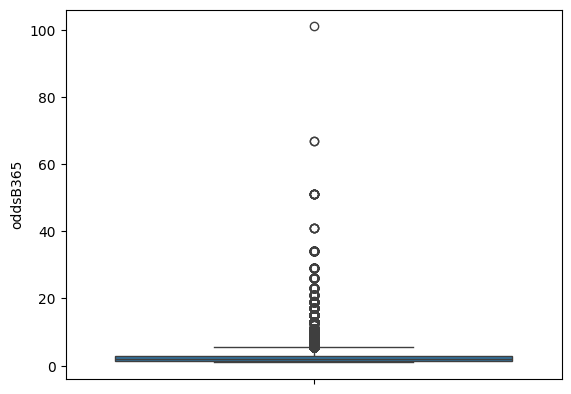

In [17]:
oddsB365 = pd.concat([df['B365A'], df['B365B']], axis=0).rename('oddsB365')
sns.boxplot(data=oddsB365)
plt.show()

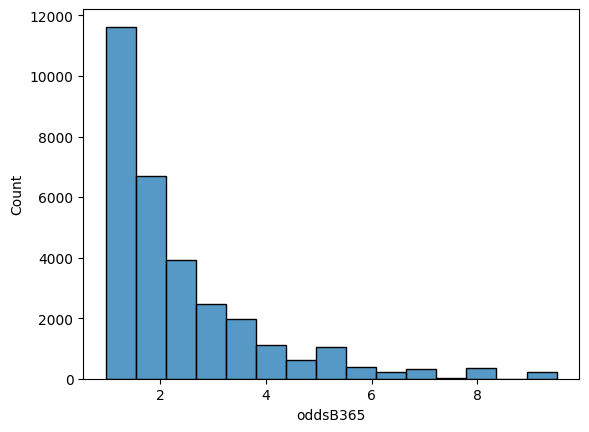

In [18]:
sns.histplot(oddsB365[oddsB365<10], bins=15)
plt.show()

In [19]:
# Vemos los partidos cuando hubo odds > 50 -> algunos se van porque no tienen partidos previos (-> % victorias previas es NaN) y otros estan ok, tiene logica

# df[(df['B365A'] > 50) | (df['B365B'] > 50)]

- Max Odds: distribución bien asimétrica a derecha. Corregimos 2 outliers

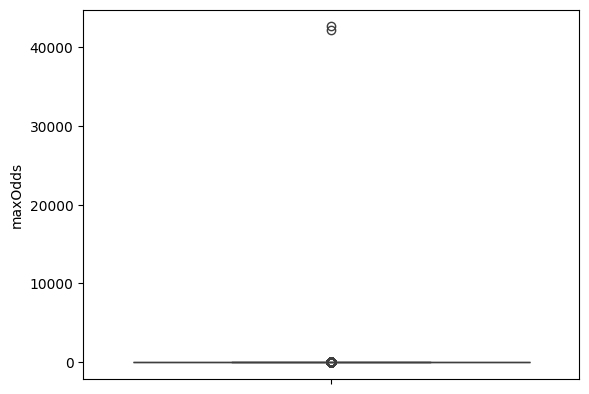

In [20]:
maxOdds = pd.concat([df['MaxA'], df['MaxB']], axis=0).rename('maxOdds')
sns.boxplot(data=maxOdds)
plt.show()

In [21]:
mask = (df['MaxA']>100) | (df['MaxB']>100)
df.loc[mask, ['MaxA']] = df.loc[mask].apply(lambda row: row['B365A'] if row['B365A']>row['AvgA'] else row['AvgA'], axis=1)
df.loc[mask, ['MaxB']] = df.loc[mask].apply(lambda row: row['B365B'] if row['B365B']>row['AvgB'] else row['AvgB'], axis=1)

# Volvemos a crear maxOdds
maxOdds = pd.concat([df['MaxA'], df['MaxB']], axis=0).rename('maxOdds')

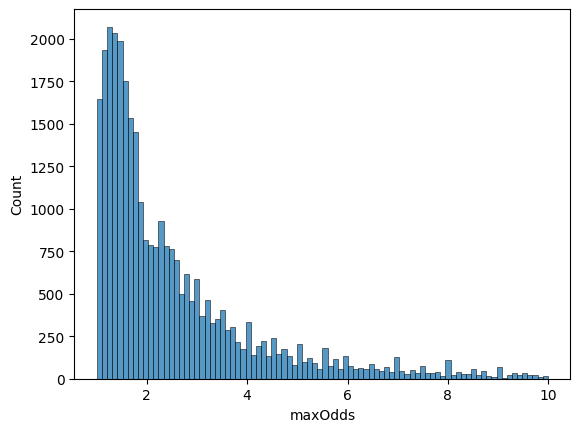

In [22]:
sns.histplot(maxOdds[maxOdds<10])
plt.show()

Variable Market Uncertainty: la mayoría de los partidos son bastante parejos

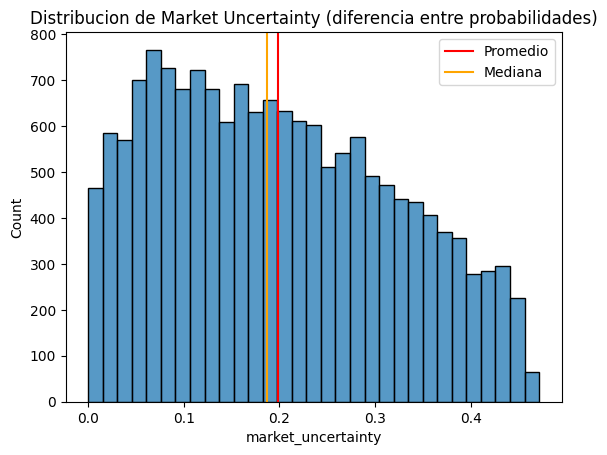

In [23]:
plt.title('Distribucion de Market Uncertainty (diferencia entre probabilidades)')
sns.histplot(df['market_uncertainty'])
plt.axvline(x=df['market_uncertainty'].mean(), color='red', label='Promedio')
plt.axvline(x=df['market_uncertainty'].median(), color='orange', label='Mediana')
plt.legend()
plt.show()

Corrección que notamos:

In [24]:
print(f'Hay {df[((df['MaxA'] - df['AvgA']) < 0) | ((df['MaxB'] - df['AvgB']) < 0)].shape[0]} registros con cuotas Max menores que Avg, lo que no tiene sentido')

Hay 8 registros con cuotas Max menores que Avg, lo que no tiene sentido


Por ende, los corregimos:

In [25]:
df.loc[(df['MaxA'] - df['AvgA']) < 0, 'MaxA'] = df.loc[(df['MaxA'] - df['AvgA']) < 0, 'AvgA']
df.loc[(df['MaxB'] - df['AvgB']) < 0, 'MaxB'] = df.loc[(df['MaxB'] - df['AvgB']) < 0, 'AvgB']

Variable B365BookmakersMargin: parece bastante normal, con una moda alrededor de 0,05

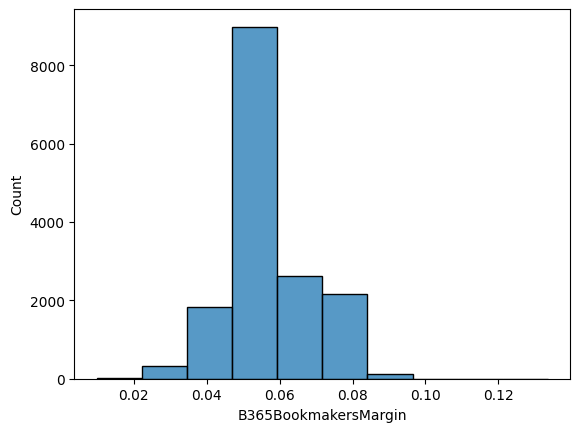

In [26]:
sns.histplot(df['B365BookmakersMargin'], bins=10)
plt.show()

Variable winrate últimos 10 partidos: vemos que la mayoria ganó aproximadamente la mitad de los partidos, con pocos ganando menos y pocos ganando más. Lo cual tiene sentido. Ya que esperaríamos una distribución bastante normal

In [27]:
winrate_10 = pd.concat([df['winrate_10_A'] , df['winrate_10_B']], axis=0).dropna()

<Axes: ylabel='Count'>

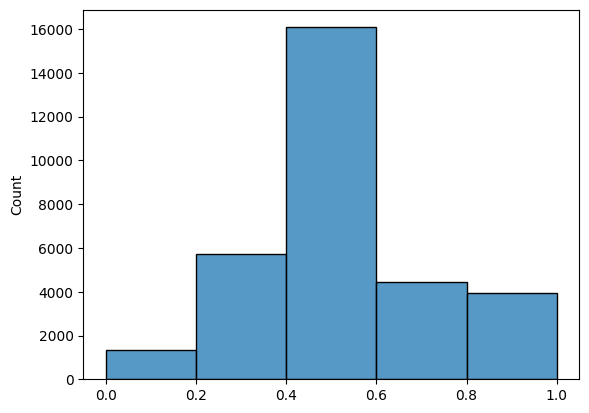

In [28]:
sns.histplot(winrate_10, bins=5)

Variable dias_ultimo_partido

In [29]:
dias_ultimo_partido = pd.concat([df['dias_ultimo_partido_A'] , df['dias_ultimo_partido_B']], axis=0).dropna()

In [30]:
dias_ultimo_partido.describe()

count    31509.000000
mean        26.201085
std         86.235090
min          0.000000
25%          2.000000
50%          3.000000
75%         21.000000
max       2654.000000
dtype: float64

In [31]:
dias_ultimo_partido.quantile(0.95)

np.float64(100.0)

<Axes: ylabel='Count'>

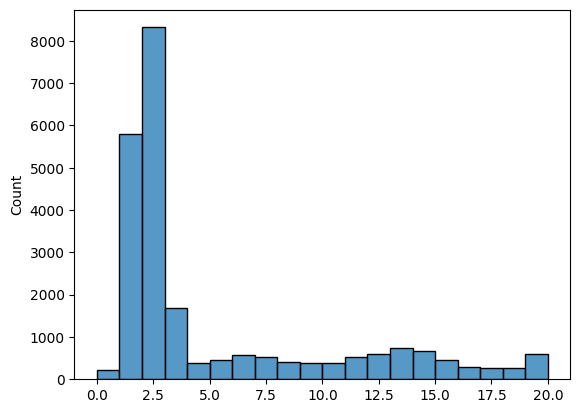

In [32]:
sns.histplot(dias_ultimo_partido[dias_ultimo_partido < dias_ultimo_partido.quantile(0.75)], bins=20)

Variable racha_victorias

In [33]:
racha_victorias = pd.concat([df['racha_victorias_A'] , df['racha_victorias_B']], axis=0)

Racha de victorias promedio: 1.12


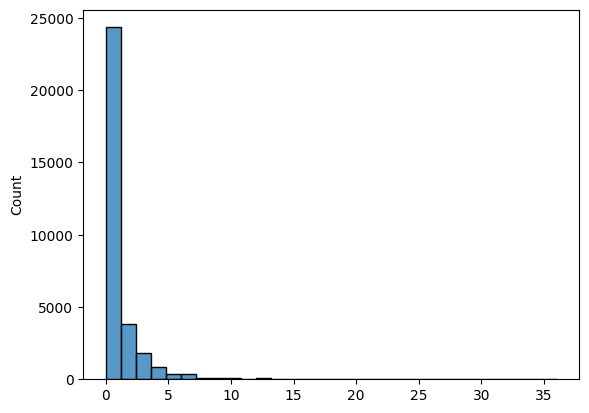

In [34]:
sns.histplot(racha_victorias, bins=30)
print(f'Racha de victorias promedio: {racha_victorias.mean():.2f}')
plt.show()

Variable partidos últimos 365 días

In [35]:
partidos_365d = pd.concat([df['partidos_365d_A'] , df['partidos_365d_B']], axis=0)

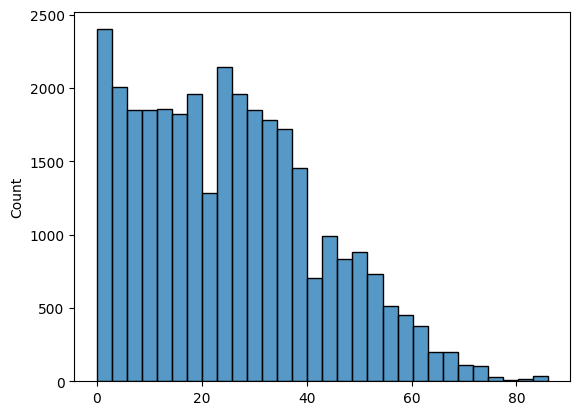

In [36]:
sns.histplot(partidos_365d, bins=30)
plt.show()

Variable de partidos previos entre ambos

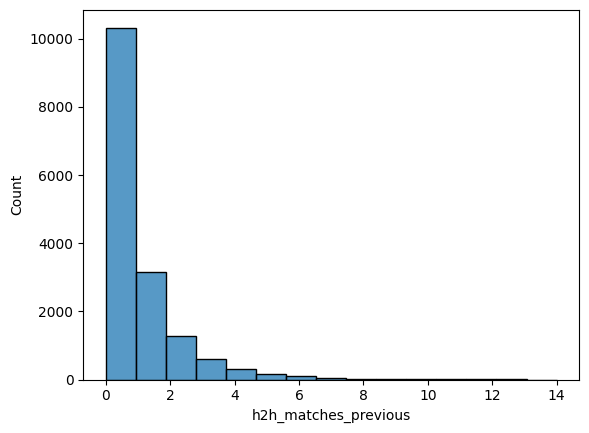

In [37]:
sns.histplot(df['h2h_matches_previous'], bins=15)
plt.show()

In [38]:
df['h2h_matches_previous'].value_counts()

h2h_matches_previous
0     10328
1      3165
2      1279
3       604
4       302
5       158
6        95
7        49
8        30
9        21
10       11
11        9
12        5
13        4
14        1
Name: count, dtype: int64

## Análisis bivariado

rankDiff vs market_uncertainty

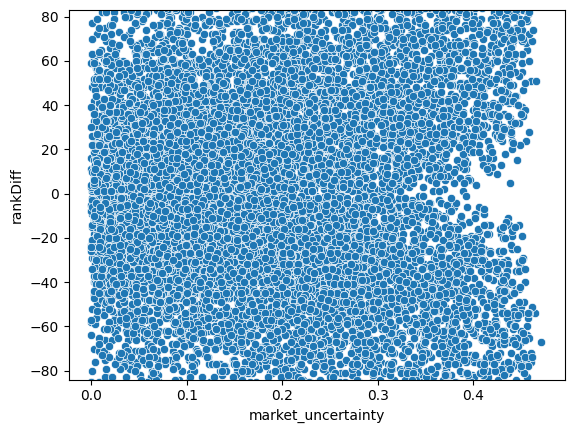

In [61]:
sns.scatterplot(data=df, x='market_uncertainty', y='rankDiff')
plt.ylim(df['rankDiff'].quantile(0.1), df['rankDiff'].quantile(0.9))
plt.show()

## Relaciones con variable target

Empezamos viendo las variables que tienen más correlación lineal con nuestro target

In [51]:
corr = df.select_dtypes(include=[np.number]).drop(columns=['Best of', 'A1', 'B1', 'A2', 'B2', 'A3', 'B3', 'A4',
                                                           'B4', 'A5', 'B5', 'setsA', 'setsB', 'setsPartido']).corr()

In [57]:
pd.concat([corr['target'].sort_values(ascending=False).head(20).reset_index(name='top_20'), corr['target'].sort_values(ascending=False).tail(20).reset_index(name='bottom_20')], axis=1)

,index,top_20,index,bottom_20
0,target,1.000000,diff_sets_5d,-0.075002
1,ProbMaxA,0.493430,diff_dias_ultimo_partido,-0.091791
2,ProbAvgA,0.493413,sets_30d_B,-0.112021
3,AvgOddsDiff,0.493413,winrate_5_B,-0.134733
4,B365ProbA,0.491521,rankA,-0.170927
5,logit_oddsA,0.488191,winrate_10_B,-0.176861
6,diff_partidos_365d,0.363896,wins_before_B,-0.177295
7,ptsDiff,0.361726,win_pct_before_B,-0.199911
8,AvgB,0.351257,partidos_365d_B,-0.229886
9,diff_win_pct_before,0.323536,PtsB,-0.247392


Target x B365 Prob A

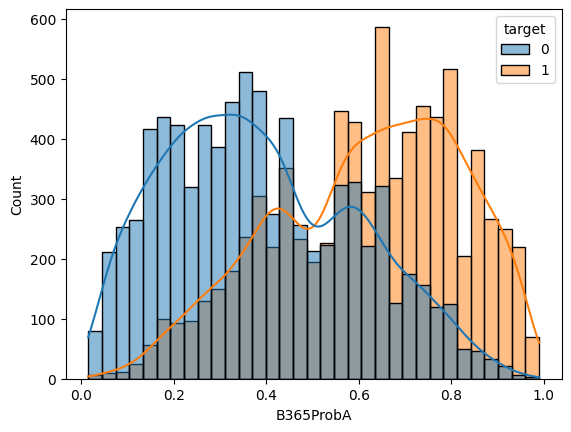

In [66]:
sns.histplot(data=df, x='B365ProbA', hue='target', kde=True)
plt.show()

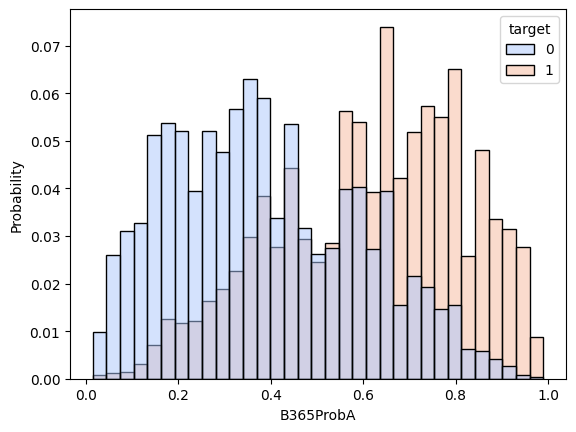

In [67]:
sns.histplot(data=df, x='B365ProbA', hue='target', stat='probability', common_norm=False, palette='coolwarm')
plt.show()

Target x Rank Diff

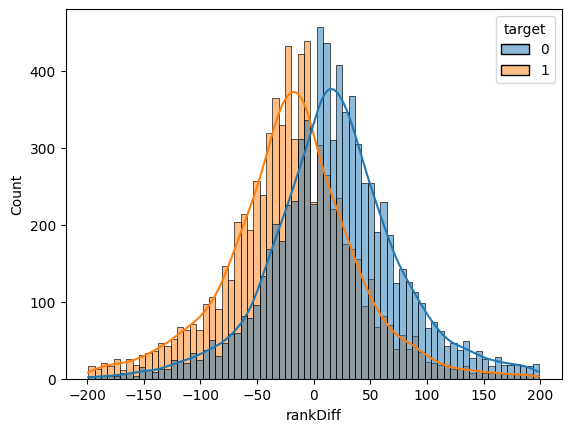

In [70]:
sns.histplot(data=df[np.abs(df['rankDiff'])<200], x='rankDiff', hue='target', kde=True)
plt.show()

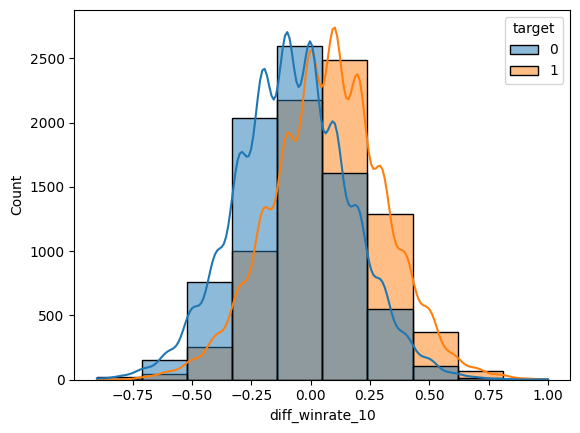

In [79]:
sns.histplot(data=df, x='diff_winrate_10', hue='target', kde=True, bins=10)
plt.show()

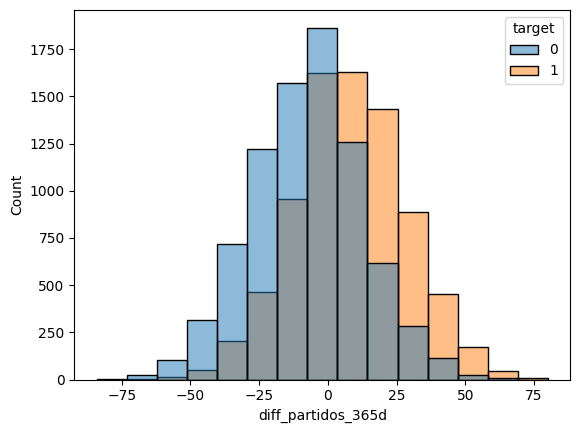

In [81]:
sns.histplot(data=df, x='diff_partidos_365d', hue='target', bins=15)
plt.show()

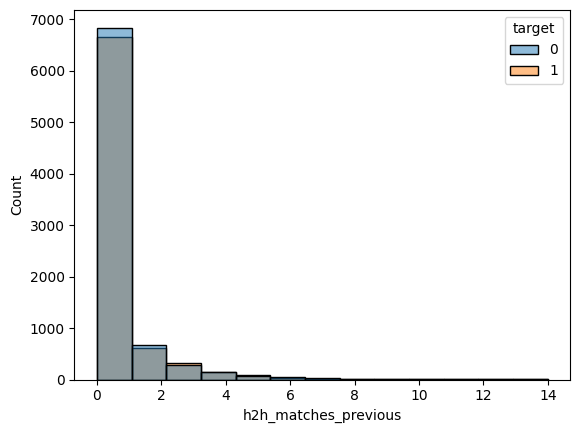

In [85]:
sns.histplot(data=df, x='h2h_matches_previous', hue='target', bins=13)
plt.show()

Creación de nuevas variables

In [ ]:
# Consenso de probabilidad entre casas (A qué tan de acuerdo están)
df['prob_consensus_A'] = (df['B365ProbA'] + df['ProbAvgA'] + df['ProbMaxA']) / 3

# Dispersión entre casas → incertidumbre de mercado más fina
df['bookmaker_std_A'] = df[['B365ProbA', 'ProbAvgA', 'ProbMaxA']].std(axis=1)

# Ratio de probabilidades (más informativo que la diferencia en extremos)
df['prob_ratio_B365'] = df['B365ProbA'] / df['B365ProbB']

# "Desacuerdo" entre B365 y el promedio del mercado
df['b365_vs_market'] = df['B365ProbA'] - df['ProbAvgA']

# Ratio en lugar de diferencia (rankDiff de 10 no es igual si es 1vs11 que 100vs110)
df['rankRatio'] = df['rankA'] / df['rankB']
df['log_rankDiff'] = np.log(df['rankA'] + 1) - np.log(df['rankB'] + 1)

# Nivel del partido (¿es un partido entre top players?)
df['rank_sum'] = df['rankA'] + df['rankB']
df['ptsRatio'] = df['PtsA'] / (df['PtsA'] + df['PtsB'])

# ¿Está mejorando o decayendo en los últimos partidos?
df['momentum_A'] = df['winrate_5_A'] - df['winrate_10_A']
df['momentum_B'] = df['winrate_5_B'] - df['winrate_10_B']
df['diff_momentum']  = df['momentum_A'] - df['momentum_B']

# Intensidad de actividad reciente
df['sets_per_day_30d_A'] = df['sets_30d_A'] / (df['dias_ultimo_partido_A'] + 1)
df['sets_per_day_30d_B'] = df['sets_30d_B'] / (df['dias_ultimo_partido_B'] + 1)
df['diff_sets_per_day'] = df['sets_per_day_30d_A'] - df['sets_per_day_30d_B']

# En best-of-5, el ranking y la forma pesan más
df['bo5_rank_diff']     = df['is_best_of_5'] * df['rankDiff']
df['bo5_momentum_diff'] = df['is_best_of_5'] * df['diff_momentum']

In [86]:
df.columns

Index(['Location', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Fecha',
       'playerA', 'playerB', 'rankA', 'rankB', 'PtsA', 'PtsB', 'B365A',
       'B365B', 'MaxA', 'MaxB', 'AvgA', 'AvgB', 'A1', 'B1', 'A2', 'B2', 'A3',
       'B3', 'A4', 'B4', 'A5', 'B5', 'setsA', 'setsB', 'target', 'setsPartido',
       'B365BookmakersMargin', 'B365ProbA', 'B365ProbB', 'ProbAvgA',
       'ProbAvgB', 'ProbMaxA', 'ProbMaxB', 'market_uncertainty',
       'OddsDiffB365', 'OddsDiffAvg', 'OddsDiffMax', 'AvgOddsDiff',
       'logit_oddsA', 'logit_oddsB', 'rankDiff', 'ptsDiff', 'winrate_5_A',
       'winrate_10_A', 'wins_before_A', 'win_pct_before_A', 'sets_5d_A',
       'sets_30d_A', 'partidos_365d_A', 'dias_ultimo_partido_A',
       'racha_victorias_A', 'winrate_5_B', 'winrate_10_B', 'wins_before_B',
       'win_pct_before_B', 'sets_5d_B', 'sets_30d_B', 'partidos_365d_B',
       'dias_ultimo_partido_B', 'racha_victorias_B', 'diff_winrate_5',
       'diff_winrate_10', 'diff_win_pct_before', 'diff_se

In [41]:
# df.to_csv('pre_ml_df.csv', index=False)